# Linear Regression — Multivariate Regression & Evaluation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/01-supervised-learning/01-linear-regression/02-multivariate-regression/notes.ipynb)

*Part 2 of 3 on Linear Regression, continuing from [the basics notebook](../01-basics/notes.ipynb). This
notebook assumes the data is already cleaned and preprocessed — see
[EDA](../../../data-preprocessing/eda/notes.ipynb),
[Feature Scaling](../../../data-preprocessing/feature-scaling/notes.ipynb), and
[Encoding Categorical Features](../../../data-preprocessing/encoding/notes.ipynb) for those general-purpose
steps.*

**Last time:** the model, MSE, gradient descent, and R² — using at most 2 of the Cars24 dataset's 17 features.
**Today:** using every feature at once, reading coefficients, how outliers affect the fitted line, Adjusted R²,
and statistical inference with StatsModels.
**Next up:** [Assumptions & Diagnostics](../03-assumptions-and-diagnostics/notes.ipynb).


## 1. Recap, and loading the data again

Each notebook in this series is self-contained and runnable on its own, so we reload the same Cars24 dataset
from [Part 1](../01-basics/notes.ipynb) here — already standardized, so every feature is on a comparable scale.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

DATA_URL = "https://raw.githubusercontent.com/28101991SUNNY/DSML-Classical-Machine-Learning-1/main/cars24-car-price-clean.csv"
DATA_PATH = "data/cars24-car-price-clean.csv"

if not os.path.exists(DATA_PATH):
    os.makedirs("data", exist_ok=True)
    pd.read_csv(DATA_URL).to_csv(DATA_PATH, index=False)

df = pd.read_csv(DATA_PATH)
df.head()

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,-1.111046,-0.801317,1.195828,0.045745,-1.310754,-1.157780,0.801317,-0.433854,-1.125683,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
1,-0.223944,0.450030,-0.737872,-0.140402,-0.537456,-0.360203,-0.450030,-0.327501,-0.333227,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
2,-0.915058,-1.426990,0.035608,-0.582501,-0.537456,-0.404885,1.426990,-0.327501,-0.789807,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
3,-0.892365,-0.801317,-0.409143,0.329620,-0.921213,-0.693085,0.801317,-0.433854,-0.905265,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
4,-0.182683,0.137194,-0.544502,0.760085,0.042999,0.010435,-0.137194,-0.246579,-0.013096,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728


In [2]:
def calculate_r_squared(y_true, y_pred):
    mean = np.mean(y_true)
    rss = np.sum((y_true - y_pred) ** 2)
    tss = np.sum((y_true - mean) ** 2)
    return 1 - (rss / tss)

## 2. Multivariate Linear Regression — using every feature at once

Time to stop leaving 15 features on the table. With $d$ features, the model equation becomes:

$$
\text{price} = w_1 x_1 + w_2 x_2 + \cdots + w_d x_d + b
$$


In [3]:
X_all = df[df.columns.drop('selling_price')].to_numpy()
Y_all = df['selling_price'].to_numpy().reshape(-1, 1)

print(X_all.shape, Y_all.shape)

full_model = LinearRegression()
full_model.fit(X_all, Y_all)
print("R-squared, all 17 features:", full_model.score(X_all, Y_all))

(19820, 17) (19820, 1)
R-squared, all 17 features: 0.9421889572026914


Compare that to the ≈0.60 the previous notebook got out of `max_power` + `mileage` alone — using every available
feature buys a large, real jump in how much of the price variance the model explains.


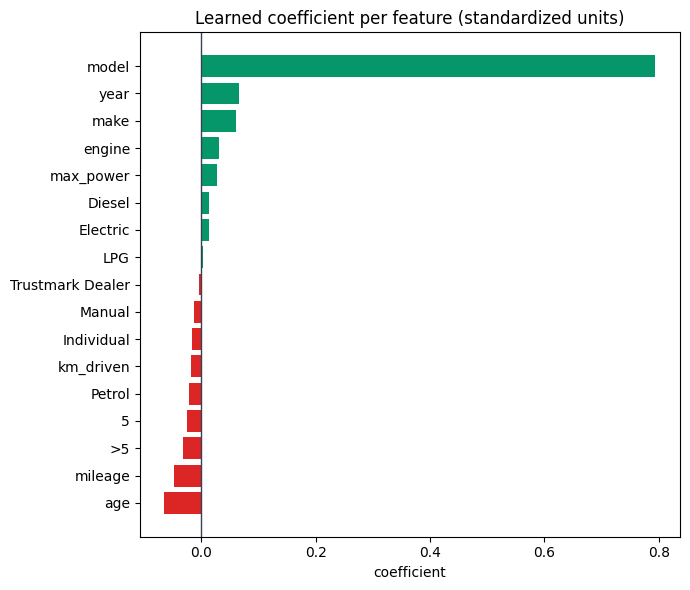

In [4]:
coef_series = pd.Series(full_model.coef_.ravel(), index=df.columns.drop('selling_price')).sort_values()

plt.figure(figsize=(7, 6))
colors = ["#DC2626" if v < 0 else "#059669" for v in coef_series.values]
plt.barh(coef_series.index, coef_series.values, color=colors)
plt.axvline(0, color="#374151", lw=1)
plt.title("Learned coefficient per feature (standardized units)")
plt.xlabel("coefficient")
plt.tight_layout()
plt.show()

### 2.1 Reading the coefficients

Since every feature is on the same standardized scale, the coefficients are directly comparable — the tallest
bars are the strongest predictors. `model` towers over everything else, which matches intuition: which specific
car model you're looking at captures a huge amount of price information (luxury sedan vs. hatchback) that no
other single column fully captures.

**The general rule for reading a coefficient**, using a toy ad-spend example instead of cars:

$$
\hat{y} = 3 + 2 \cdot \text{TV} + 3 \cdot \text{SocialMedia}
$$

- Holding TV spend fixed, a +1 unit increase in Social Media spend → **+3** units of sales.
- Holding Social Media fixed, a +1 unit increase in TV spend → **+2** units of sales.
- Social Media has the stronger effect here — its coefficient has the larger magnitude.

Flip the sign and the story flips too: $\hat{y} = 3 + 2\cdot\text{TV} - 3\cdot\text{SocialMedia}$ would mean more
social spend *decreases* predicted sales (maybe a campaign that backfired).

> **Key rule:** the coefficient's *magnitude* tells you influence strength, its *sign* tells you direction — but
> only when every feature is on the same scale (see
> [Feature Scaling](../../../data-preprocessing/feature-scaling/notes.ipynb)). Comparing raw, unscaled
> coefficients directly is meaningless — a coefficient of 50,000 on a feature measured in single digits can be
> weaker than a coefficient of 0.001 on a feature measured in millions.


## 3. The impact of outliers on the regression line

The regression line minimizes the *sum of squared* errors — and because errors are squared, one point sitting
far from the rest exerts a wildly disproportionate pull on where the line ends up. This is a property of the
algorithm itself, worth understanding on top of the general outlier-detection techniques covered in
[EDA](../../../data-preprocessing/eda/notes.ipynb) (see its "Detecting outliers" section).


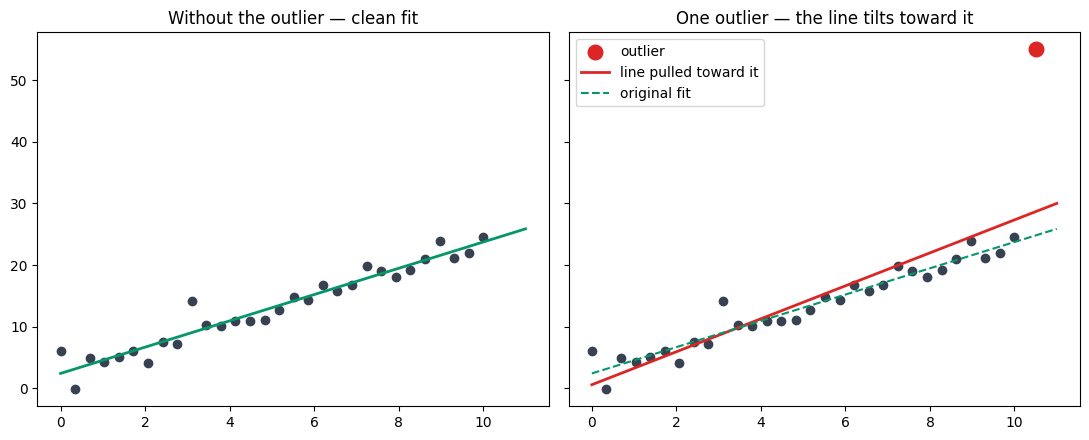

Slope without outlier: 2.13
Slope with outlier:    2.67


In [5]:
rng = np.random.default_rng(3)
clean_x = np.linspace(0, 10, 30)
clean_y = 2 * clean_x + 3 + rng.normal(0, 1.5, size=30)

outlier_x = np.append(clean_x, 10.5)
outlier_y = np.append(clean_y, 55)  # one wildly extreme point

m_clean, c_clean = np.polyfit(clean_x, clean_y, 1)
m_out, c_out = np.polyfit(outlier_x, outlier_y, 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

xs = np.linspace(0, 11, 50)
axes[0].scatter(clean_x, clean_y, color="#374151")
axes[0].plot(xs, m_clean * xs + c_clean, color="#059669", lw=2)
axes[0].set_title("Without the outlier — clean fit")

axes[1].scatter(outlier_x[:-1], outlier_y[:-1], color="#374151")
axes[1].scatter([outlier_x[-1]], [outlier_y[-1]], color="#DC2626", s=110, zorder=5, label="outlier")
axes[1].plot(xs, m_out * xs + c_out, color="#DC2626", lw=2, label="line pulled toward it")
axes[1].plot(xs, m_clean * xs + c_clean, color="#059669", lw=1.5, ls="--", label="original fit")
axes[1].set_title("One outlier — the line tilts toward it")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Slope without outlier: {m_clean:.2f}")
print(f"Slope with outlier:    {m_out:.2f}")

Like a rubber band stretched toward a pin, the further the outlier sits from the main cluster, the harder it
drags the line — at the cost of fitting every *other* point worse. That squared-error sensitivity is exactly why
outlier detection and treatment (IQR rule, Z-score, or visual inspection — all covered in the EDA notes linked
above) matters *before* fitting a linear model, not after.


## 4. R² isn't the whole story — Adjusted R²

**The flaw:** R² can only go up (or stay flat) as you add more features — even features that are pure random
noise. A model with 50 useless features will show a *higher* R² than one with 5 genuinely good ones. Plain R²
alone can't tell a real improvement from padding.

**The fix:**

$$
\text{Adj. } R^2 = 1 - (1 - R^2) \cdot \frac{n - 1}{n - p - 1}
$$

where $n$ is the number of samples and $p$ the number of features. Adding a genuinely useless feature now
*decreases* Adjusted R², because the penalty term grows while $R^2$ barely moves.


In [6]:
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    df[df.columns.drop('selling_price')], df['selling_price'], test_size=0.2, random_state=2
)

full_model2 = LinearRegression().fit(X_train_all, y_train_all)
r2_test = full_model2.score(X_test_all, y_test_all)

n = len(y_test_all)
p = X_test_all.shape[1]
adj_r2 = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)

print(f"R² (test):          {r2_test:.4f}")
print(f"Adjusted R² (test): {adj_r2:.4f}")

R² (test):          0.9455
Adjusted R² (test): 0.9453


> **When to use which:** plain R² for a quick sanity check; Adjusted R² whenever you're comparing models with a
> *different* number of features — it's the fairer judge, since it won't reward padding a model with junk
> columns just to nudge the score up.


## 5. Statistical inference with StatsModels

Scikit-learn is built for prediction accuracy. **StatsModels** is built for statistical inference — it hands
back p-values, confidence intervals, and diagnostic tests that scikit-learn doesn't compute at all.

| | Scikit-Learn | StatsModels |
|---|---|---|
| Primary goal | Prediction accuracy | Statistical inference |
| Coefficients | ✅ | ✅ |
| p-values | ❌ | ✅ |
| Confidence intervals | ❌ | ✅ |
| Diagnostic tests | ❌ | ✅ |


In [7]:
import statsmodels.api as sm

X_sm = sm.add_constant(X_train_all)  # StatsModels doesn't add an intercept automatically
sm_model = sm.OLS(y_train_all.values, X_sm).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                 1.588e+04
Date:                Sun, 30 Aug 2026   Prob (F-statistic):               0.00
Time:                        10:35:02   Log-Likelihood:                -7.3180
No. Observations:               15856   AIC:                             48.64
Df Residuals:                   15839   BIC:                             179.0
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             7.664e-05      0.002  

/tmp/ipykernel_2085/1255880531.py:4: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  sm_model = sm.OLS(y_train_all.values, X_sm).fit()


**Reading the table:**

| Column | Meaning |
|---|---|
| `coef` | Estimated coefficient for the feature |
| `std err` | Standard error — uncertainty in that estimate |
| `t` | t-statistic: `coef / std err` |
| `P>\|t\|` | p-value — probability of seeing this coefficient if the true effect were zero. Below 0.05 is conventionally "significant" |
| `[0.025 0.975]` | 95% confidence interval for the coefficient |

Notice the printed warning about the condition number being very large — that's StatsModels flagging the exact
problem the next notebook digs into in depth: strong multicollinearity among the features (in our case, `year`
and `age` are literally the same information, since `age` is derived from `year`).


## 6. Summary — revision cheat sheet

**Multivariate regression:** using all $d$ features at once — $\hat{y} = w_1x_1 + \cdots + w_dx_d + b$ — buys a
large, real jump in R² over any 1-2 feature model. Coefficients are only directly comparable when every feature
is on the same scale.

**Outlier sensitivity:** squared error means the fitted line is pulled disproportionately toward extreme points
— a reason to handle outliers (see [EDA](../../../data-preprocessing/eda/notes.ipynb)) before fitting, not after.

**Evaluation:**
- *Adjusted R²* — $R^2$ penalized for feature count; use it whenever comparing models with a different number of
  features, since plain R² never decreases from adding *any* feature, useful or not.
- *StatsModels* — reach for it over scikit-learn when you need p-values, confidence intervals, or diagnostic
  tests, not just predictions.

**Next up:** [Assumptions & Diagnostics](../03-assumptions-and-diagnostics/notes.ipynb) — the 5 assumptions that
make a regression model *trustworthy*, and detecting/fixing multicollinearity with VIF.
